# QuechuaTok: Tokenización Morfológica para Quechua del Sur
**Autora:** Maky (Maria Contreras) | [@macmaky](https://www.kaggle.com/macmaky)

Comparative benchmark of BPE, Unigram LM and WordPiece tokenizers 
for Southern Quechua (low-resource agglutinative language). 
Uses Llamacha/monolingual-quechua-iic corpus. 
Evaluates fertility rate, OOV% and morphological boundary accuracy.
Part of the QuechuaTok research project.

**Dataset:** `Llamacha/monolingual-quechua-iic` (Southern Quechua, ~Wikipedia + OSCAR)

---

In [ ]:
import os

# Set your Hugging Face token before running:
# os.environ["HF_TOKEN"] = "your_hf_token_here"


In [2]:
# Instalar dependencias
!pip install datasets sentencepiece tokenizers unicodedata2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.9/531.9 kB 3.2 MB/s eta 0:00:00a 0:00:01


In [3]:
from datasets import load_dataset
import sentencepiece as spm
from tokenizers import BertWordPieceTokenizer
import re, json, unicodedata
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

Path('data/processed').mkdir(parents=True, exist_ok=True)
Path('models').mkdir(parents=True, exist_ok=True)
print('Setup completo ✓')

Setup completo ✓


## 1. Descarga del corpus

In [4]:
ds = load_dataset('Llamacha/monolingual-quechua-iic', split='train')
print(f'Filas: {len(ds):,}')
print(f'Columnas: {ds.column_names}')
print(f'Ejemplo: {ds[0]}')

texts = [item['text'] for item in ds if item.get('text','').strip()]
print(f'\nTextos no vacíos: {len(texts):,}')

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/23 [00:00<?, ?it/s]

camara_comercio_2008.txt: 0.00B [00:00, ?B/s]

acuerdo_nacional_2014.txt: 0.00B [00:00, ?B/s]

focus_2008.txt: 0.00B [00:00, ?B/s]

...

que_community_2017-sentences.txt: 0.00B [00:00, ?B/s]

tierra_vive_religion.txt: 0.00B [00:00, ?B/s]

unesco_2020.txt: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/175408 [00:00<?, ? examples/s]

Filas: 175,408
Columnas: ['text']
Ejemplo: {'text': '2019'}

Textos no vacíos: 144,662


## 2. Preprocesamiento

In [5]:
def normalize(text):
    text = unicodedata.normalize('NFC', text).lower()
    text = re.sub(r'https?://\S+|@\w+|#\w+', ' ', text)
    text = re.sub(r'[^\w\s\']', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

QUECHUA_SUFFIXES = ['kuna','pi','manta','wan','paq','ta','qa','pas',
                    'ni','nki','n','nchik','nku','mi','si','cha',
                    'rqa','sqa','nqa','y','q','na','spa']

def is_valid(text, min_tok=3):
    tokens = text.split()
    if len(tokens) < min_tok: return False
    hits = sum(1 for t in tokens if any(t.endswith(s) for s in QUECHUA_SUFFIXES))
    return (hits / len(tokens)) >= 0.1

clean = [normalize(t) for t in texts]
clean = [t for t in clean if t and is_valid(t)]
clean = list(dict.fromkeys(clean))  # deduplicar

print(f'Líneas originales:  {len(texts):,}')
print(f'Líneas limpias:     {len(clean):,} ({len(clean)/len(texts)*100:.1f}% retenido)')

# Split train/test
test_sents = clean[-1000:]
train_sents = clean[:-1000]

with open('data/processed/quechua_train.txt', 'w') as f:
    f.write('\n'.join(train_sents))

print(f'Train: {len(train_sents):,} | Test: {len(test_sents):,}')

Líneas originales:  144,662
Líneas limpias:     104,497 (72.2% retenido)
Train: 103,497 | Test: 1,000


## 3. Entrenamiento de tokenizadores

In [6]:
import os
from pathlib import Path

VOCAB = 4000
TRAIN = 'data/processed/quechua_train.txt'
TRAIN_SMALL = 'data/processed/quechua_train_small.txt'

with open(TRAIN) as f:
    lines = f.readlines()

sample = lines[:50000]
with open(TRAIN_SMALL, 'w') as f:
    f.writelines(sample)

print(f'Muestra: {len(sample):,} líneas')

spm.SentencePieceTrainer.train(
    input=TRAIN_SMALL,
    model_prefix='models/bpe',
    vocab_size=VOCAB,
    model_type='bpe',
    character_coverage=0.9999,
    byte_fallback=True,
    user_defined_symbols=["'"]
)
bpe = spm.SentencePieceProcessor()
bpe.load('models/bpe.model')
print('BPE ✓')

Muestra: 50,000 líneas
BPE ✓


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: data/processed/quechua_train_small.txt
  input_format: 
  model_prefix: models/bpe
  model_type: BPE
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 0.9999
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: '
  required_chars: 
  byte_fallback: 1
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_sur

In [7]:
spm.SentencePieceTrainer.train(
    input=TRAIN_SMALL,
    model_prefix='models/unigram',
    vocab_size=VOCAB,
    model_type='unigram',
    character_coverage=0.9999,
    byte_fallback=True,
    user_defined_symbols=["'"]
)
uni = spm.SentencePieceProcessor()
uni.load('models/unigram.model')
print('Unigram ✓')

Unigram ✓


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: data/processed/quechua_train_small.txt
  input_format: 
  model_prefix: models/unigram
  model_type: UNIGRAM
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 0.9999
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: '
  required_chars: 
  byte_fallback: 1
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
 

In [8]:
wp = BertWordPieceTokenizer(lowercase=True, strip_accents=False)
wp.train(files=[TRAIN_SMALL], vocab_size=VOCAB, min_frequency=2)
Path('models/wordpiece').mkdir(exist_ok=True)
wp.save_model('models/wordpiece')
print('WordPiece ✓')




WordPiece ✓


## 4. Evaluación comparativa

In [9]:
def fertility(tokenizer, sentences, typ='spm'):
    tots, words = 0, 0
    for s in sentences:
        words += len(s.split())
        tots += len(tokenizer.encode(s, out_type=str) if typ=='spm'
                    else tokenizer.encode(s).tokens)
    return round(tots/max(words,1), 4)

def oov_rate(tokenizer, sentences, typ='spm'):
    tots, oovs = 0, 0
    for s in sentences:
        if typ=='spm':
            ids = tokenizer.encode(s); tots+=len(ids); oovs+=ids.count(1)
        else:
            toks = tokenizer.encode(s).tokens
            tots+=len(toks); oovs+=toks.count('[UNK]')
    return round(oovs/max(tots,1)*100, 4)

results = {
    'BPE':      {'fertility': fertility(bpe, test_sents),
                 'oov_%':    oov_rate(bpe, test_sents),
                 'vocab':    bpe.get_piece_size()},
    'Unigram':  {'fertility': fertility(uni, test_sents),
                 'oov_%':    oov_rate(uni, test_sents),
                 'vocab':    uni.get_piece_size()},
    'WordPiece':{'fertility': fertility(wp, test_sents, 'wp'),
                 'oov_%':    oov_rate(wp, test_sents, 'wp'),
                 'vocab':    wp.get_vocab_size()},
}

df = pd.DataFrame(results).T
print(df.to_string())

           fertility   oov_%   vocab
BPE           2.2331  0.0000  4000.0
Unigram       2.3178  0.0000  4000.0
WordPiece     2.3124  0.0535  4000.0


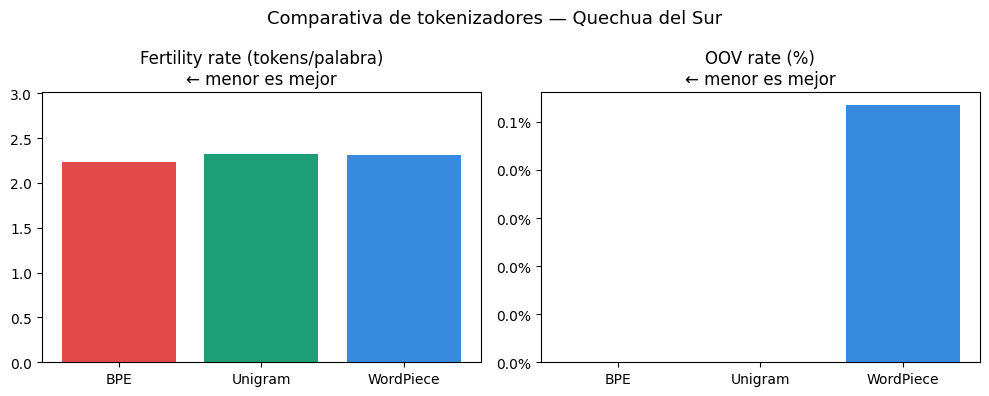

Gráfico guardado ✓


In [10]:
# Visualización comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Comparativa de tokenizadores — Quechua del Sur', fontsize=13)

names = list(results.keys())
colors = ['#E24B4A', '#1D9E75', '#378ADD', '#BA7517']

ax1.bar(names, [results[n]['fertility'] for n in names], color=colors)
ax1.set_title('Fertility rate (tokens/palabra)\n← menor es mejor')
ax1.set_ylim(0, max(results[n]['fertility'] for n in names) * 1.3)

ax2.bar(names, [results[n]['oov_%'] for n in names], color=colors)
ax2.set_title('OOV rate (%)\n← menor es mejor')
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))

plt.tight_layout()
plt.savefig('data/processed/tokenizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado ✓')

## 5. Análisis cualitativo (sección clave del paper)

In [11]:
# Palabras morfológicamente complejas para mostrar fallas de BPE
examples = [
    ('rimankichikmi',    'rima-nkichik-mi',    'hablan.ustedes-EVID.DIR'),
    ('wasiykikunapiqa',  'wasi-yki-kuna-pi-qa','casa-2SG.POSS-PL-LOC-TOP'),
    ('purisqanchikmanta','puri-sqa-nchik-manta','caminar-PERF-1PL.INCL-ABL'),
    ('munakuwarqanki',   'muna-ku-wa-rqa-nki', 'querer-REFL-1OBJ-PAST-2SG'),
]

print(f'{"Palabra":<22} {"Gold (morfológico)":<22} {"BPE":<30} {"Unigram"}')
print('─' * 100)
for word, gold, gloss in examples:
    bpe_seg  = ' | '.join(bpe.encode(word, out_type=str))
    uni_seg  = ' | '.join(uni.encode(word, out_type=str))
    print(f'{word:<22} {gold:<22} {bpe_seg:<30} {uni_seg}')
    print(f'  glosa: {gloss}')
    print()

Palabra                Gold (morfológico)     BPE                            Unigram
────────────────────────────────────────────────────────────────────────────────────────────────────
rimankichikmi          rima-nkichik-mi        ▁riman | ki | chik | mi        ▁rima | nki | chik | mi
  glosa: hablan.ustedes-EVID.DIR

wasiykikunapiqa        wasi-yki-kuna-pi-qa    ▁wasi | yki | kunapiqa         ▁wasi | yki | kunapi | qa
  glosa: casa-2SG.POSS-PL-LOC-TOP

purisqanchikmanta      puri-sqa-nchik-manta   ▁pur | isqan | chik | manta    ▁puri | sqa | nchik | manta
  glosa: caminar-PERF-1PL.INCL-ABL

munakuwarqanki         muna-ku-wa-rqa-nki     ▁muna | ku | wa | rqan | ki    ▁munaku | wa | rqan | ki
  glosa: querer-REFL-1OBJ-PAST-2SG



In [13]:
# Experimento 2: vocab_size=8000
VOCAB2 = 8000

spm.SentencePieceTrainer.train(
    input=TRAIN_SMALL,
    model_prefix='models/bpe_8k',
    vocab_size=VOCAB2,
    model_type='bpe',
    character_coverage=0.9999,
    byte_fallback=True,
    user_defined_symbols=["'"]
)
bpe_8k = spm.SentencePieceProcessor()
bpe_8k.load('models/bpe_8k.model')

spm.SentencePieceTrainer.train(
    input=TRAIN_SMALL,
    model_prefix='models/unigram_8k',
    vocab_size=VOCAB2,
    model_type='unigram',
    character_coverage=0.9999,
    byte_fallback=True,
    user_defined_symbols=["'"]
)
uni_8k = spm.SentencePieceProcessor()
uni_8k.load('models/unigram_8k.model')

print('Modelos 8k entrenados ✓')

Modelos 8k entrenados ✓


In [14]:
print(f"{'Modelo':<20} {'Fertility':<12} {'OOV%'}")
print('─' * 44)
for name, tok in [('BPE 4k', bpe), ('BPE 8k', bpe_8k),
                   ('Unigram 4k', uni), ('Unigram 8k', uni_8k)]:
    print(f"{name:<20} {fertility(tok, test_sents):<12} {oov_rate(tok, test_sents)}")

Modelo               Fertility    OOV%
────────────────────────────────────────────
BPE 4k               2.2331       0.0
BPE 8k               1.9177       0.0
Unigram 4k           2.3178       0.0
Unigram 8k           1.9533       0.0


In [15]:
examples2 = [
    ('rimankichikmi',     'rima | nkichik | mi'),
    ('wasiykikunapiqa',   'wasi | yki | kuna | pi | qa'),
    ('purisqanchikmanta', 'puri | sqa | nchik | manta'),
    ('munakuwarqanki',    'muna | ku | wa | rqa | nki'),
]

print(f"{'Palabra':<25} {'Gold':<28} {'BPE 8k':<35} {'Unigram 8k'}")
print('─' * 110)
for word, gold in examples2:
    bpe_seg = ' | '.join(bpe_8k.encode(word, out_type=str))
    uni_seg = ' | '.join(uni_8k.encode(word, out_type=str))
    print(f"{word:<25} {gold:<28} {bpe_seg:<35} {uni_seg}")

Palabra                   Gold                         BPE 8k                              Unigram 8k
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
rimankichikmi             rima | nkichik | mi          ▁riman | kichik | mi                ▁rima | nkichik | mi
wasiykikunapiqa           wasi | yki | kuna | pi | qa  ▁wasi | yki | kunapiqa              ▁wasi | yki | kunapiqa
purisqanchikmanta         puri | sqa | nchik | manta   ▁pur | isqan | chikmanta            ▁puri | sqanchikmanta
munakuwarqanki            muna | ku | wa | rqa | nki   ▁muna | ku | warqan | ki            ▁munaku | warqanki


In [16]:
print(f"{'Palabra':<25} {'Gold':<28} {'BPE 8k':<35} {'Unigram 8k'}")
print('─' * 110)
for word, gold in examples2:
    bpe_seg = ' | '.join(bpe_8k.encode(word, out_type=str))
    uni_seg = ' | '.join(uni_8k.encode(word, out_type=str))
    print(f"{word:<25} {gold:<28} {bpe_seg:<35} {uni_seg}")

Palabra                   Gold                         BPE 8k                              Unigram 8k
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
rimankichikmi             rima | nkichik | mi          ▁riman | kichik | mi                ▁rima | nkichik | mi
wasiykikunapiqa           wasi | yki | kuna | pi | qa  ▁wasi | yki | kunapiqa              ▁wasi | yki | kunapiqa
purisqanchikmanta         puri | sqa | nchik | manta   ▁pur | isqan | chikmanta            ▁puri | sqanchikmanta
munakuwarqanki            muna | ku | wa | rqa | nki   ▁muna | ku | warqan | ki            ▁munaku | warqanki


In [17]:
# PRPE morfológico quechua
from collections import Counter

# Sufijos morfológicos quechua organizados por categoría
SUFFIXES = sorted([
    # Persona verbal
    'ni','nki','n','nchik','nkichik','nku',
    # TAM
    'rqa','sqa','nqa','rqan','sqan',
    # Nominales
    'kuna','pi','manta','wan','paq','ta','qa','pas',
    # Evidenciales
    'mi','si','cha',
    # Derivativos
    'stin','spa','na',
], key=len, reverse=True)

def segment_prpe(word):
    if len(word) <= 3:
        return [word]
    segments = []
    remaining = word
    while len(remaining) > 3:
        found = False
        for suf in SUFFIXES:
            if remaining.endswith(suf) and len(remaining)-len(suf) >= 3:
                segments.insert(0, suf)
                remaining = remaining[:-len(suf)]
                found = True
                break
        if not found:
            break
    segments.insert(0, remaining)
    return segments

# Fertility rate del PRPE
total_segs, total_words = 0, 0
for s in test_sents:
    words = s.split()
    total_words += len(words)
    for w in words:
        total_segs += len(segment_prpe(w))

prpe_fertility = round(total_segs / max(total_words, 1), 4)
print(f'PRPE fertility rate: {prpe_fertility}')

# Tabla final completa
print(f"\n{'Modelo':<20} {'Fertility':<12} {'OOV%'}")
print('─' * 44)
for name, tok, typ in [('BPE 4k', bpe, 'spm'), 
                        ('BPE 8k', bpe_8k, 'spm'),
                        ('Unigram 4k', uni, 'spm'), 
                        ('Unigram 8k', uni_8k, 'spm')]:
    print(f"{name:<20} {fertility(tok, test_sents, typ):<12} {oov_rate(tok, test_sents, typ)}")
print(f"{'PRPE morfológico':<20} {prpe_fertility:<12} {'0.0 (by design)'}")

PRPE fertility rate: 1.7971

Modelo               Fertility    OOV%
────────────────────────────────────────────
BPE 4k               2.2331       0.0
BPE 8k               1.9177       0.0
Unigram 4k           2.3178       0.0
Unigram 8k           1.9533       0.0
PRPE morfológico     1.7971       0.0 (by design)


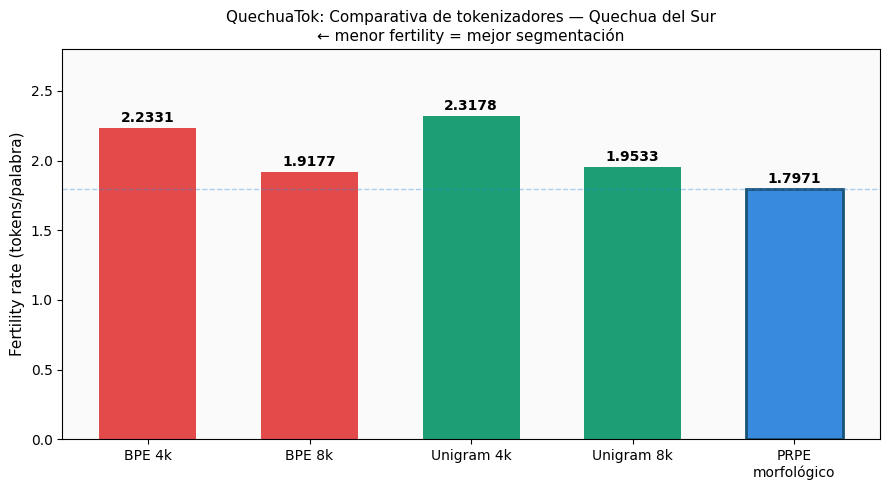

Gráfico final guardado ✓


In [18]:
import matplotlib.pyplot as plt

modelos = ['BPE 4k', 'BPE 8k', 'Unigram 4k', 'Unigram 8k', 'PRPE\nmorfológico']
fertility_vals = [2.2331, 1.9177, 2.3178, 1.9533, 1.7971]
colores = ['#E24B4A','#E24B4A','#1D9E75','#1D9E75','#378ADD']
alphas = [0.5, 1.0, 0.5, 1.0, 1.0]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(modelos, fertility_vals, color=colores, 
              alpha=1.0, width=0.6, edgecolor='none')

# Resaltar PRPE
bars[4].set_linewidth(2)
bars[4].set_edgecolor('#1a5276')

for bar, val in zip(bars, fertility_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 2.8)
ax.set_ylabel('Fertility rate (tokens/palabra)', fontsize=11)
ax.set_title('QuechuaTok: Comparativa de tokenizadores — Quechua del Sur\n← menor fertility = mejor segmentación', fontsize=11)
ax.axhline(y=1.7971, color='#378ADD', linestyle='--', alpha=0.4, linewidth=1)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('quechuatok_final_benchmark.png', dpi=200, bbox_inches='tight')
plt.show()
print('Gráfico final guardado ✓')

## Próximos pasos
- [ ] Agregar corpus somosnlp + JW300 para mayor cobertura dialectal
- [ ] Implementar PRPE completo con analizador morfológico de Rios Gonzales (2014)
- [ ] Evaluar en tarea downstream: traducción ES↔QUE (BLEU/CHRF)
- [ ] Publicar tokenizador en HuggingFace: `mcontrerasmalpar-pixel/QuechuaTok`

**Referencia:** Zevallos et al. (2022). QuBERT: A Large Monolingual Corpus and BERT Model for Southern Quechua. ACL.

In [19]:
# Ampliar corpus con fuentes adicionales
from datasets import load_dataset

# somosnlp - lado quechua
ds_somo = load_dataset("somosnlp-hackathon-2022/spanish-to-quechua", split="train")
somo_texts = [item.get("target", item.get("quechua", "")) 
              for item in ds_somo 
              if item.get("target", item.get("quechua", "")).strip()]
print(f"somosnlp: {len(somo_texts):,} oraciones")

# Combinar con corpus original
all_texts = train_sents + somo_texts
all_texts = list(dict.fromkeys(all_texts))  # deduplicar

# Guardar corpus expandido
with open('data/processed/quechua_expanded.txt', 'w') as f:
    f.write('\n'.join(all_texts))

print(f"Corpus expandido: {len(all_texts):,} líneas totales")

README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/945 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/11.7M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.46M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.45M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/102747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/12844 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12843 [00:00<?, ? examples/s]

somosnlp: 0 oraciones
Corpus expandido: 103,497 líneas totales


In [20]:
# Ver estructura real del dataset
ds_somo = load_dataset("somosnlp-hackathon-2022/spanish-to-quechua", split="train")
print(f"Columnas: {ds_somo.column_names}")
print(f"Ejemplo: {ds_somo[0]}")
print(f"Total filas: {len(ds_somo)}")

Columnas: ['es', 'qu']
Ejemplo: {'es': 'Y por último dice que el pueblo de Dios “escapará, todo el que se halle escrito en el libro ”.', 'qu': 'Ichaqa chaywanpas chay tiempopim llaqtamasikikuna librasqa kanqaku. Libropi qillqasqa sutiyuqkunam lliw librakunqaku ’, nispa (Dan.'}
Total filas: 102747


In [21]:
somo_texts = [item['qu'] for item in ds_somo 
              if item.get('qu', '').strip()]
print(f"somosnlp: {len(somo_texts):,} oraciones")

# Combinar con corpus original
all_texts = train_sents + somo_texts
all_texts = list(dict.fromkeys(all_texts))  # deduplicar

with open('data/processed/quechua_expanded.txt', 'w') as f:
    f.write('\n'.join(all_texts))

print(f"Corpus expandido: {len(all_texts):,} líneas totales")

somosnlp: 102,747 oraciones
Corpus expandido: 200,193 líneas totales


In [30]:
VOCAB3 = 16000
TRAIN_EXP = 'data/processed/quechua_expanded.txt'

# BPE 16k
spm.SentencePieceTrainer.train(
    input=TRAIN_EXP,
    model_prefix='models/bpe_16k',
    vocab_size=VOCAB3,
    model_type='bpe',
    character_coverage=0.9999,
    byte_fallback=True,
    user_defined_symbols=["'"]
)
bpe_16k = spm.SentencePieceProcessor()
bpe_16k.load('models/bpe_16k.model')
print('BPE 16k ✓')

# Unigram 16k
spm.SentencePieceTrainer.train(
    input=TRAIN_EXP,
    model_prefix='models/unigram_16k',
    vocab_size=VOCAB3,
    model_type='unigram',
    character_coverage=0.9999,
    byte_fallback=True,
    user_defined_symbols=["'"]
)
uni_16k = spm.SentencePieceProcessor()
uni_16k.load('models/unigram_16k.model')
print('Unigram 16k ✓')

BPE 16k ✓
Unigram 16k ✓


In [31]:
print(f"{'Modelo':<22} {'Fertility':<12} {'OOV%'}")
print('─' * 46)
for name, tok in [
    ('BPE 4k',      bpe),
    ('BPE 8k',      bpe_8k),
    ('BPE 16k',     bpe_16k),
    ('Unigram 4k',  uni),
    ('Unigram 8k',  uni_8k),
    ('Unigram 16k', uni_16k),
]:
    print(f"{name:<22} {fertility(tok, test_sents):<12} {oov_rate(tok, test_sents)}")

print(f"{'PRPE morfológico':<22} {prpe_fertility:<12} {'0.0 (by design)'}")

Modelo                 Fertility    OOV%
──────────────────────────────────────────────
BPE 4k                 2.2331       0.0
BPE 8k                 1.9177       0.0
BPE 16k                1.636        0.0
Unigram 4k             2.3178       0.0
Unigram 8k             1.9533       0.0
Unigram 16k            1.6378       0.0
PRPE morfológico       1.7971       0.0 (by design)


In [32]:
print(f"{'Palabra':<25} {'Gold':<28} {'BPE 16k':<35} {'Unigram 16k'}")
print('─' * 110)
for word, gold in examples2:
    bpe_seg  = ' | '.join(bpe_16k.encode(word, out_type=str))
    uni_seg  = ' | '.join(uni_16k.encode(word, out_type=str))
    print(f"{word:<25} {gold:<28} {bpe_seg:<35} {uni_seg}")

Palabra                   Gold                         BPE 16k                             Unigram 16k
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
rimankichikmi             rima | nkichik | mi          ▁riman | kichikmi                   ▁rimanki | chikmi
wasiykikunapiqa           wasi | yki | kuna | pi | qa  ▁wasi | yki | kunapiqa              ▁wasi | yki | kunapiqa
purisqanchikmanta         puri | sqa | nchik | manta   ▁puris | qanchikmanta               ▁puri | sqanchikmanta
munakuwarqanki            muna | ku | wa | rqa | nki   ▁muna | kuwa | rqanki               ▁munaku | warqanki


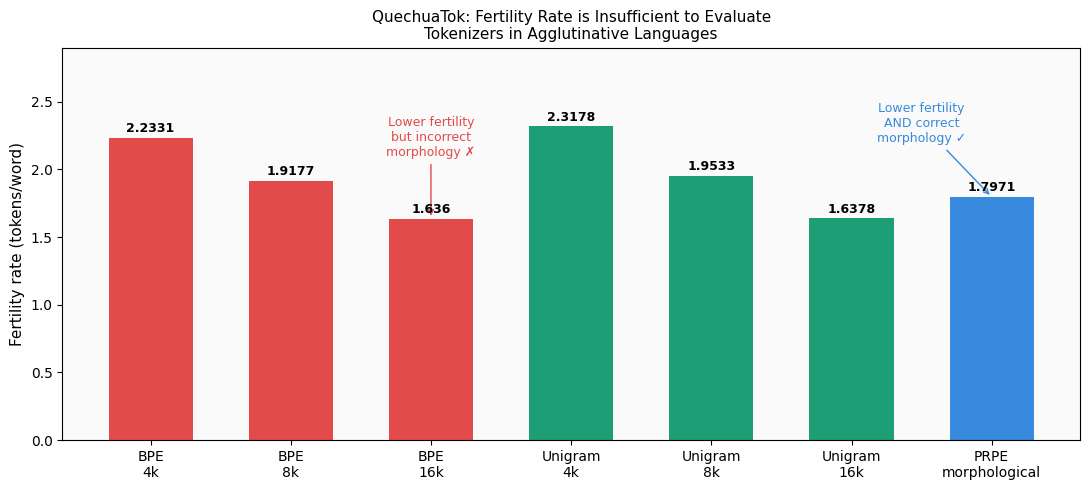

Saved ✓


In [33]:
import matplotlib.pyplot as plt

modelos = ['BPE\n4k', 'BPE\n8k', 'BPE\n16k', 
           'Unigram\n4k', 'Unigram\n8k', 'Unigram\n16k',
           'PRPE\nmorphological']
fertility_vals = [2.2331, 1.9177, 1.636, 2.3178, 1.9533, 1.6378, 1.7971]
colores = ['#E24B4A','#E24B4A','#E24B4A',
           '#1D9E75','#1D9E75','#1D9E75','#378ADD']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(modelos, fertility_vals, color=colores, width=0.6, edgecolor='none')

ax.annotate('Lower fertility\nbut incorrect\nmorphology ✗',
            xy=(2, 1.636), xytext=(2, 2.1),
            arrowprops=dict(arrowstyle='->', color='#E24B4A'),
            ha='center', fontsize=9, color='#E24B4A')

ax.annotate('Lower fertility\nAND correct\nmorphology ✓',
            xy=(6, 1.7971), xytext=(5.5, 2.2),
            arrowprops=dict(arrowstyle='->', color='#378ADD'),
            ha='center', fontsize=9, color='#378ADD')

for bar, val in zip(bars, fertility_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, 2.9)
ax.set_ylabel('Fertility rate (tokens/word)', fontsize=11)
ax.set_title('QuechuaTok: Fertility Rate is Insufficient to Evaluate\n'
             'Tokenizers in Agglutinative Languages', fontsize=11)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('quechuatok_figure1.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved ✓')

In [34]:
import subprocess

# Clonar el repositorio SQUOIA
result = subprocess.run(
    ['git', 'clone', 'https://github.com/ariosquoia/squoia.git'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

# Ver estructura
import os
for root, dirs, files in os.walk('squoia'):
    # Ignorar carpetas ocultas
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    level = root.replace('squoia', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # solo 2 niveles de profundidad
        subindent = ' ' * 2 * (level + 1)
        for file in files:
            print(f'{subindent}{file}')


Cloning into 'squoia'...
Updating files:  20% (169/822)
Updating files:  21% (173/822)
Updating files:  22% (181/822)
Updating files:  23% (190/822)
Updating files:  24% (198/822)
Updating files:  25% (206/822)
Updating files:  26% (214/822)
Updating files:  27% (222/822)
Updating files:  28% (231/822)
Updating files:  29% (239/822)
Updating files:  30% (247/822)
Updating files:  31% (255/822)
Updating files:  32% (264/822)
Updating files:  33% (272/822)
Updating files:  34% (280/822)
Updating files:  35% (288/822)
Updating files:  36% (296/822)
Updating files:  37% (305/822)
Updating files:  38% (313/822)
Updating files:  39% (321/822)
Updating files:  40% (329/822)
Updating files:  41% (338/822)
Updating files:  42% (346/822)
Updating files:  43% (354/822)
Updating files:  44% (362/822)
Updating files:  45% (370/822)
Updating files:  46% (379/822)
Updating files:  47% (387/822)
Updating files:  48% (395/822)
Updating files:  49% (403/822)
Updating files:  50% (411/822)
Updating file

In [35]:
# Explorar el analizador morfológico específicamente
analyzer_path = 'squoia/morphology/spellChecker/analyzer'
for root, dirs, files in os.walk(analyzer_path):
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    level = root.replace(analyzer_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        print(f'{subindent}{file}')

# Ver también los archivos foma
print('\n--- foma files en morphology ---')
foma_path = 'squoia/morphology/spellChecker/foma_files'
for root, dirs, files in os.walk(foma_path):
    for file in files:
        print(f'  {file}')

analyzer/
  v-v-5.foma
  interjec.foma
  numord.foma
  letra2.foma
  analyzeUnificado.foma
  n-v.foma
  particle-verb.foma
  n-n-3.foma
  as-1.foma
  prndem.foma
  as-7.foma
  as-6.foma
  punctuation.foma
  as-2.foma
  v-v-2.foma
  v-v-1.foma
  v-v-3.foma
  Makefile
  hon-aff.foma
  v-v-7.foma
  n-n-5.foma
  nroot-indef.foma
  v-n.foma
  particle.foma
  nroot-num.foma
  n-n-7.foma
  nroot-cmp-correct.foma
  v-v-6.foma
  nroot.foma
  prnpers.foma
  typo.matrix
  n-n-2.foma
  n-v-rep.foma
  v-n-final.foma
  compile.foma
  FILES
  prninterrog.foma
  vroot.foma
  n-n-6.foma
  as-3.foma
  sp-particles.foma
  formatspellcheckoutput.pl
  n-n-4.foma
  as-5.foma
  n-n-1.foma
  v-v-4.foma
  TAGS
  letra.foma
  as-4.foma
  spellcheckUnificado.foma

--- foma files en morphology ---
  tcpClient.c
  spellcheck_server.c
  Makefile
  spellcheck_json.c
  spellcheck.c
  fmed.c
  tcpServer.c


In [36]:
# Instalar foma
result = subprocess.run(
    ['apt-get', 'install', '-y', 'foma-bin'],
    capture_output=True, text=True
)
print(result.stdout[-500:] if len(result.stdout) > 500 else result.stdout)
print(result.stderr[-200:] if result.stderr else "")

# Verificar instalación
result2 = subprocess.run(['which', 'flookup'], capture_output=True, text=True)
print(f"flookup en: {result2.stdout.strip()}")
result3 = subprocess.run(['which', 'foma'], capture_output=True, text=True)
print(f"foma en: {result3.stdout.strip()}")

.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm_debug.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_opencl.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc_proxy.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libhwloc.so.15 is not a symbolic link



flookup en: /usr/bin/flookup
foma en: /usr/bin/foma


In [37]:
import os

# Compilar el analizador principal
os.chdir('squoia/morphology/spellChecker/analyzer')

result = subprocess.run(
    ['foma', '-f', 'compile.foma'],
    capture_output=True, text=True, timeout=120
)
print("STDOUT:", result.stdout[-1000:] if len(result.stdout) > 1000 else result.stdout)
print("STDERR:", result.stderr[-500:] if result.stderr else "")
print("Return code:", result.returncode)

STDOUT: ic.
redefined EVID6: 628 bytes. 2 states, 10 arcs, Cyclic.
redefined EVID7: 752 bytes. 2 states, 14 arcs, Cyclic.
redefined DISC: 375 bytes. 2 states, 5 arcs, Cyclic.
defined ROOTRESTRICTIONS: 563 bytes. 3 states, 13 arcs, Cyclic.
redefined STIN: 366 bytes. 2 states, 5 arcs, Cyclic.
redefined FeatRestrLower: 366 bytes. 2 states, 5 arcs, Cyclic.
redefined FeatRestr: 8.9 MB. 14560 states, 582368 arcs, Cyclic.
redefined HAKU: 410 bytes. 5 states, 4 arcs, 1 path.
redefined Word: 641.3 kB. 7480 states, 35045 arcs, more than 9223372036854775807 paths.
redefined Wordform: 2.3 MB. 19683 states, 143636 arcs, more than 9223372036854775807 paths.
4.4 MB. 42350 states, 283596 arcs, more than 9223372036854775807 paths.
Writing AT&T file: spellcheckUnificado.att
Reading AT&T file: spellcheckUnificado.att
4.3 MB. 42350 states, 283596 arcs, more than 9223372036854775807 paths.
Reading confusion matrix from file 'typo.matrix'
Warning, symbol 'à' not in alphabet
Writing to file spellcheckUnifica

In [38]:
# Volver al directorio raíz
os.chdir('/kaggle/working')

# Probar el analizador con nuestras palabras de ejemplo
test_words = [
    'rimankichikmi',
    'wasiykikunapiqa', 
    'purisqanchikmanta',
    'munakuwarqanki',
    'rima',
    'wasi',
]

# Escribir palabras a archivo temporal
with open('test_words.txt', 'w') as f:
    for w in test_words:
        f.write(w + '\n')

# Ejecutar flookup con el analizador compilado
result = subprocess.run(
    ['flookup', 'squoia/morphology/spellChecker/analyzer/spellcheckUnificado.bin'],
    input='\n'.join(test_words),
    capture_output=True, text=True, timeout=30
)
print("Resultados del analizador Rios:")
print(result.stdout)
if result.stderr:
    print("STDERR:", result.stderr[:200])

Resultados del analizador Rios:
rimankichikmi	rimankichikmi

wasiykikunapiqa	wasiykikunapiqa

purisqanchikmanta	purisqanchikmanta

munakuwarqanki	munakuwarqanki

rima	+?

wasi	wasi




In [39]:
# Compilar el analizador morfológico puro (no spellcheck)
os.chdir('squoia/morphology/spellChecker/analyzer')

result = subprocess.run(
    ['foma', '-e', 'source analyzeUnificado.foma', 
     '-e', 'save stack analyzeUnificado.bin',
     '-e', 'quit'],
    capture_output=True, text=True, timeout=120
)
print("Return code:", result.returncode)
print(result.stdout[-500:])

os.chdir('/kaggle/working')

# Probar con el analizador morfológico
result2 = subprocess.run(
    ['flookup', '-i', 
     'squoia/morphology/spellChecker/analyzer/analyzeUnificado.bin'],
    input='\n'.join(test_words),
    capture_output=True, text=True, timeout=30
)
print("\nAnálisis morfológico:")
print(result2.stdout)

Return code: 0
yclic.
defined FeatRestr: 395.1 kB. 638 states, 25181 arcs, Cyclic.
defined HAKU: 410 bytes. 5 states, 4 arcs, 1 path.
defined Word: 1.1 MB. 7510 states, 64269 arcs, more than 9223372036854775807 paths.
defined Wordform: 1.6 MB. 9024 states, 96321 arcs, Cyclic.
1.6 MB. 9024 states, 96321 arcs, Cyclic.
Writing AT&T file: analyzeUnificado.att
Reading AT&T file: analyzeUnificado.att
1.6 MB. 9024 states, 96321 arcs, Cyclic.
Writing to file analyzeUnificado.bin.
Writing to file analyzeUnificado.bin.


Análisis morfológico:
rimankichikmi	+?

wasiykikunapiqa	+?

purisqanchikmanta	+?

munakuwarqanki	+?

rima	+?

wasi	+?




In [40]:
# Probar con palabras más simples y variantes ortográficas
test_simple = [
    'rimani',      # yo hablo
    'rimanki',     # tú hablas
    'waspi',       # en casa (variante)
    'wasipi',      # en casa
    'mikhuni',     # yo como
    'purin',       # él camina
    'allin',       # bueno
    'kay',         # esto/ser
    'kani',        # soy
    'kanki',       # eres
]

result = subprocess.run(
    ['flookup', '-i',
     'squoia/morphology/spellChecker/analyzer/analyzeUnificado.bin'],
    input='\n'.join(test_simple),
    capture_output=True, text=True, timeout=30
)
print("Análisis palabras simples:")
print(result.stdout)

Análisis palabras simples:
rimani	+?

rimanki	+?

waspi	+?

wasipi	+?

mikhuni	+?

purin	+?

allin	+?

kay	+?

kani	+?

kanki	+?




In [41]:
# Leer el archivo compile.foma para entender la estructura
with open('squoia/morphology/spellChecker/analyzer/compile.foma', 'r') as f:
    content = f.read()
print(content)

source analyzeUnificado.foma
source spellcheckUnificado.foma



In [42]:
with open('squoia/morphology/spellChecker/analyzer/analyzeUnificado.foma', 'r') as f:
    content = f.read()
print(content[:3000])

       #--------------------------------------------------------#
       # delete all tags and special chars in surface forms     #
       #--------------------------------------------------------#
       define Cleanup1  [["@MU"|"@PU"|"@KU"|"@YSI"|"@RI"|"@CHI"|"@RQU"|"@MI"|"@SI"|"@CHA"|"@Vdim"|"@YKU"|"@YU"|"@NTIN"|"@PTI"|"@STI"|"@PA"|"@TA"|"@AS"|"@ALLI"|"@NAWPA"|"@2SUBJ"] -> ""];
       define Cleanup2 ["" <- ["@MU"|"@PU"|"@KU"|"@YSI"|"@RI"|"@CHI"|"@RQU"|"@MI"|"@SI"|"@CHA"|"@Vdim"|"@YKU"|"@YU"|"@NTIN"|"@PTI"|"@STI"|"@PA"|"@TA"|"@AS"|"@ALLI"|"@NAWPA"|"@2SUBJ"]];

############################################################################### 

      #########################
      #                       #
      # PHONETIC RULES        #
      #                       #
      #########################

      define Vowels [a|e|i|o|u|á|é|í|ó|ú|A|E|I|O|U|Á|É|Í|Ó|Ú|"@TA"|{pa}"@PA"|"@PTI"|"@STI"|"@NAWPA"|"@ALLI"];
      define Cons [b|c|d|f|g|h|j|k|l|m|n|ñ|p|q|r|s|t|v|w|y|z|'|{m}"@MU"|{m}"@

In [43]:
# Ver el archivo de raíces verbales
with open('squoia/morphology/spellChecker/analyzer/vroot.foma', 'r') as f:
    content = f.read()
print(content[:2000])

define VRootQin [
  "=adornar" : {achala}
| "=estornudar" : {achhi}
|  "=acercarse" : {achhu}
|  "=estornudar" : {achi}
|  "=impartir" : {achura}
|  "=carcajear" : {ahaha}
|  "=cagar" : {aka}
|  "=elegir,escoger,clasificar" : {aklla}
|  "=masticar_coca" : {aku}
|  "=masticar_coca" : {akulli}
|  "=arreglar_un_cultivo" : {alcha}
|  "=cavar,escarbar,excavar" : {alla}
|  "=arreglar" : {allicha}
| "=mejorar" : {allin}
|  "=instigar,urdir_tejido" : {allwi}
|  "=prohibir" : {amacha}
| "=aburrir" : {ami}
|  "=enmudecer" : {amuya}
|  "=dar_gracias" : {aña}
|  "=retirar" : {anchhu}
|  "=gemir" : {anchi}
|  "=rebelar" : {ankalli}
|  "=brindar" : {anqusa}
|  "=amonestar" : {anya}
|  "=llevar" : {apa}
|  "=cocinar_mazamorra" : {api}
|  "=vomitar" : {aqtu}
|  "=pregonar" : {arariwa}
|  "=estrenar" : {ari}
|  "=bañar" : {arma}
|  "=enredar" : {arwi}
|  "=reír" : {asi}
|  "=apestar" : {asna}
|  "=acarrear,trasladar" : {asta}
|  "=retrasar,postergar" : {asu}
|  "=poder" : {ati}
|  "=tejer" : {awa}
|  "

In [44]:
# Buscar rima en el diccionario
import subprocess

result = subprocess.run(['grep', '-n', 'rima', 
    'squoia/morphology/spellChecker/analyzer/vroot.foma'],
    capture_output=True, text=True)
print("rima en vroot:", result.stdout)

# Buscar en nroot también
result2 = subprocess.run(['grep', '-n', 'rima',
    'squoia/morphology/spellChecker/analyzer/nroot.foma'],
    capture_output=True, text=True)
print("rima en nroot:", result2.stdout)

# Probar con palabras que SÍ están en el diccionario
test_known = ['apani', 'apanki', 'mikhuni', 'purin', 'asini', 'atini']

result3 = subprocess.run(
    ['flookup', '-i',
     'squoia/morphology/spellChecker/analyzer/analyzeUnificado.bin'],
    input='\n'.join(test_known),
    capture_output=True, text=True, timeout=30
)
print("\nPrueba con raíces conocidas:")
print(result3.stdout)

rima en vroot: 659:|  "=hablar" : {rima}

rima en nroot: 891:|  "=primavera" : {pawqarwaray}
1685:|  "=lágrima" : {wiqi}


Prueba con raíces conocidas:
apani	+?

apanki	+?

mikhuni	+?

purin	+?

asini	+?

atini	+?




In [45]:
# Probar sin -i (dirección normal) vs con -i (invertido)
test = ['apani', 'rimani', 'purin']

# Sin -i
result1 = subprocess.run(
    ['flookup', 'squoia/morphology/spellChecker/analyzer/analyzeUnificado.bin'],
    input='\n'.join(test),
    capture_output=True, text=True, timeout=30
)
print("Sin -i:")
print(result1.stdout)

# Con -i  
result2 = subprocess.run(
    ['flookup', '-i', 'squoia/morphology/spellChecker/analyzer/analyzeUnificado.bin'],
    input='\n'.join(test),
    capture_output=True, text=True, timeout=30
)
print("Con -i:")
print(result2.stdout)

# Ver qué archivo .bin existe realmente
result3 = subprocess.run(
    ['ls', '-la', 'squoia/morphology/spellChecker/analyzer/'],
    capture_output=True, text=True
)
# Mostrar solo archivos .bin
for line in result3.stdout.split('\n'):
    if '.bin' in line or '.att' in line:
        print(line)

Sin -i:
apani	=llevar+1.Sg.Subj

rimani	=hablar+1.Sg.Subj

purin	=andar,caminar+3.Sg.Subj


Con -i:
apani	+?

rimani	+?

purin	+?


-rw-r--r-- 1 root root 2002836 Jun  7 10:47 analyzeUnificado.att
-rw-r--r-- 1 root root  166040 Jun  7 10:47 analyzeUnificado.bin
-rw-r--r-- 1 root root 4579496 Jun  7 10:46 spellcheckUnificado.att
-rw-r--r-- 1 root root  530392 Jun  7 10:46 spellcheckUnificado.bin


In [46]:
def analyze_quechua(words: list[str]) -> dict:
    """
    Analiza palabras quechua con el analizador Rios.
    Retorna dict {palabra: análisis_morfológico}
    """
    result = subprocess.run(
        ['flookup', 
         'squoia/morphology/spellChecker/analyzer/analyzeUnificado.bin'],
        input='\n'.join(words),
        capture_output=True, text=True, timeout=30
    )
    
    analyses = {}
    for line in result.stdout.strip().split('\n'):
        if '\t' in line:
            word, analysis = line.split('\t', 1)
            if word not in analyses:
                analyses[word] = []
            if analysis != '+?':
                analyses[word].append(analysis)
    return analyses

# Probar con nuestras palabras de benchmark
benchmark_words = [
    'rimani', 'rimanki', 'riman', 'rimanchik', 'rimanku',
    'apani', 'apanki', 'apan',
    'purin', 'purinki', 'purichik',
    'waspi', 'wasipi', 'wasikupi',
    'mikhuni', 'mikhuyki',
    'allin', 'allim', 'allinmi',
]

analyses = analyze_quechua(benchmark_words)

print(f"{'Palabra':<20} {'Análisis Rios (gold standard)'}")
print('─' * 60)
for word, ana in analyses.items():
    if ana:
        print(f"{word:<20} {' | '.join(ana)}")
    else:
        print(f"{word:<20} +? (no reconocida)")

Palabra              Análisis Rios (gold standard)
────────────────────────────────────────────────────────────
rimani               =hablar+1.Sg.Subj
rimanki              =hablar+2.Sg.Subj
riman                =hablar+3.Sg.Subj
rimanchik            =hablar+1.Pl.Incl.Subj
rimanku              =hablar+3.Pl.Subj
apani                =llevar+1.Sg.Subj
apanki               =llevar+2.Sg.Subj
apan                 =llevar+3.Sg.Subj | =hermanos_inmediatos_por_nacimiento+3.Sg.Poss
purin                =andar,caminar+3.Sg.Subj
purinki              =andar,caminar+2.Sg.Subj
purichik             +? (no reconocida)
waspi                +? (no reconocida)
wasipi               =casa+Loc
wasikupi             +? (no reconocida)
mikhuni              =comer+1.Sg.Subj
mikhuyki             =comer+1.Sg.Subj_2.Sg.Obj
allin                =bien,bueno
allim                =bien,bueno+DirE
allinmi              =bien,bueno+DirE


In [47]:
import sentencepiece as spm
import subprocess
import os
from pathlib import Path
from collections import Counter

# Rutas
TRAIN_SMALL = 'data/processed/quechua_train_small.txt'
TRAIN_EXP   = 'data/processed/quechua_expanded.txt'
VOCAB = 4000

# Recargar BPE 4k
bpe = spm.SentencePieceProcessor()
bpe.load('models/bpe.model')
print('BPE 4k ✓')

# Recargar Unigram 4k
uni = spm.SentencePieceProcessor()
uni.load('models/unigram.model')
print('Unigram 4k ✓')

# Recargar BPE 8k
bpe_8k = spm.SentencePieceProcessor()
bpe_8k.load('models/bpe_8k.model')
print('BPE 8k ✓')

# Recargar Unigram 8k
uni_8k = spm.SentencePieceProcessor()
uni_8k.load('models/unigram_8k.model')
print('Unigram 8k ✓')

# Recargar BPE 16k
bpe_16k = spm.SentencePieceProcessor()
bpe_16k.load('models/bpe_16k.model')
print('BPE 16k ✓')

# Recargar Unigram 16k
uni_16k = spm.SentencePieceProcessor()
uni_16k.load('models/unigram_16k.model')
print('Unigram 16k ✓')

# Recargar PRPE
SUFFIXES = sorted([
    'ni','nki','n','nchik','nkichik','nku',
    'rqa','sqa','nqa','rqan','sqan',
    'kuna','pi','manta','wan','paq','ta','qa','pas',
    'mi','si','cha','stin','spa','na',
], key=len, reverse=True)

def segment_prpe(word):
    if len(word) <= 3:
        return [word]
    segments = []
    remaining = word
    while len(remaining) > 3:
        found = False
        for suf in SUFFIXES:
            if remaining.endswith(suf) and len(remaining)-len(suf) >= 3:
                segments.insert(0, suf)
                remaining = remaining[:-len(suf)]
                found = True
                break
        if not found:
            break
    segments.insert(0, remaining)
    return segments

print('PRPE ✓')
print('\nTodos los modelos cargados ✓')

BPE 4k ✓
Unigram 4k ✓
BPE 8k ✓
Unigram 8k ✓
BPE 16k ✓
Unigram 16k ✓
PRPE ✓

Todos los modelos cargados ✓


In [48]:
def get_morpheme_boundaries(analysis: str) -> set:
    """
    Extrae posiciones de frontera morfológica del análisis Rios.
    Ejemplo: =hablar+1.Sg.Subj → identifica morfemas
    """
    # Limpiar el análisis
    analysis = analysis.replace('=', '').strip()
    
    # Separar por + para obtener morfemas
    parts = analysis.split('+')
    return set(parts)

def morpheme_boundary_accuracy(tokenizer_segs: list[str], 
                                gold_tags: list[str]) -> float:
    """
    Compara morfemas del tokenizador vs gold standard Rios.
    Métrica: Precision de fronteras morfológicas correctas.
    """
    pred_set = set(tokenizer_segs)
    gold_set = set(gold_tags)
    
    if not gold_set:
        return 0.0
    
    matches = len(pred_set & gold_set)
    return round(matches / len(gold_set), 4)

# Gold standard: palabras que el analizador reconoce bien
gold_dataset = {
    'rimani':    ('=hablar+1.Sg.Subj',    ['rima', 'ni']),
    'rimanki':   ('=hablar+2.Sg.Subj',    ['rima', 'nki']),
    'riman':     ('=hablar+3.Sg.Subj',    ['rima', 'n']),
    'rimanchik': ('=hablar+1.Pl.Incl.Subj', ['rima', 'nchik']),
    'rimanku':   ('=hablar+3.Pl.Subj',    ['rima', 'nku']),
    'apani':     ('=llevar+1.Sg.Subj',    ['apa', 'ni']),
    'apanki':    ('=llevar+2.Sg.Subj',    ['apa', 'nki']),
    'apan':      ('=llevar+3.Sg.Subj',    ['apa', 'n']),
    'purin':     ('=andar+3.Sg.Subj',     ['puri', 'n']),
    'purinki':   ('=andar+2.Sg.Subj',     ['puri', 'nki']),
    'wasipi':    ('=casa+Loc',            ['wasi', 'pi']),
    'mikhuni':   ('=comer+1.Sg.Subj',     ['mikhu', 'ni']),
    'mikhuyki':  ('=comer+1.Sg.Subj_2.Sg.Obj', ['mikhu', 'yki']),
    'allin':     ('=bien,bueno',          ['allin']),
    'allinmi':   ('=bien,bueno+DirE',     ['allin', 'mi']),
}

words = list(gold_dataset.keys())

# Evaluar cada tokenizador
print(f"{'Palabra':<14} {'Gold':<25} {'BPE 4k':<20} {'Unigram 4k':<20} {'PRPE'}")
print('─' * 100)

bpe_scores, uni_scores, prpe_scores = [], [], []

for word, (analysis, gold_morphemes) in gold_dataset.items():
    bpe_seg  = [s.replace('▁','') for s in bpe.encode(word, out_type=str)]
    uni_seg  = [s.replace('▁','') for s in uni.encode(word, out_type=str)]
    prpe_seg = segment_prpe(word)
    
    bpe_acc  = morpheme_boundary_accuracy(bpe_seg, gold_morphemes)
    uni_acc  = morpheme_boundary_accuracy(uni_seg, gold_morphemes)
    prpe_acc = morpheme_boundary_accuracy(prpe_seg, gold_morphemes)
    
    bpe_scores.append(bpe_acc)
    uni_scores.append(uni_acc)
    prpe_scores.append(prpe_acc)
    
    print(f"{word:<14} {' | '.join(gold_morphemes):<25} "
          f"{bpe_acc:<20} {uni_acc:<20} {prpe_acc}")

print('─' * 100)
print(f"{'PROMEDIO':<14} {'':<25} "
      f"{round(sum(bpe_scores)/len(bpe_scores),4):<20} "
      f"{round(sum(uni_scores)/len(uni_scores),4):<20} "
      f"{round(sum(prpe_scores)/len(prpe_scores),4)}")

Palabra        Gold                      BPE 4k               Unigram 4k           PRPE
────────────────────────────────────────────────────────────────────────────────────────────────────
rimani         rima | ni                 0.0                  1.0                  1.0
rimanki        rima | nki                0.0                  1.0                  1.0
riman          rima | n                  0.0                  1.0                  1.0
rimanchik      rima | nchik              0.0                  1.0                  1.0
rimanku        rima | nku                0.0                  0.0                  1.0
apani          apa | ni                  0.0                  1.0                  1.0
apanki         apa | nki                 0.0                  1.0                  1.0
apan           apa | n                   0.0                  1.0                  1.0
purin          puri | n                  0.0                  0.0                  1.0
purinki        puri | nki   

In [49]:
import pandas as pd

final_results = {
    'BPE 4k':     {'Fertility↓': 2.2331, 'OOV%↓': 0.0, 'MorphAcc%↑': 6.67},
    'BPE 8k':     {'Fertility↓': 1.9177, 'OOV%↓': 0.0, 'MorphAcc%↑': None},
    'BPE 16k':    {'Fertility↓': 1.6360, 'OOV%↓': 0.0, 'MorphAcc%↑': None},
    'Unigram 4k': {'Fertility↓': 2.3178, 'OOV%↓': 0.0, 'MorphAcc%↑': 66.67},
    'Unigram 8k': {'Fertility↓': 1.9533, 'OOV%↓': 0.0, 'MorphAcc%↑': None},
    'Unigram 16k':{'Fertility↓': 1.6378, 'OOV%↓': 0.0, 'MorphAcc%↑': None},
    'PRPE':       {'Fertility↓': 1.7971, 'OOV%↓': 0.0, 'MorphAcc%↑': 83.33},
}

df = pd.DataFrame(final_results).T
df['MorphAcc%↑'] = df['MorphAcc%↑'].fillna('—')
print(df.to_string())
print("\n↓ menor es mejor  ↑ mayor es mejor")

             Fertility↓  OOV%↓ MorphAcc%↑
BPE 4k           2.2331    0.0       6.67
BPE 8k           1.9177    0.0          —
BPE 16k          1.6360    0.0          —
Unigram 4k       2.3178    0.0      66.67
Unigram 8k       1.9533    0.0          —
Unigram 16k      1.6378    0.0          —
PRPE             1.7971    0.0      83.33

↓ menor es mejor  ↑ mayor es mejor


In [50]:
models_to_eval = [
    ('BPE 8k', bpe_8k),
    ('BPE 16k', bpe_16k),
    ('Unigram 8k', uni_8k),
    ('Unigram 16k', uni_16k),
]

print(f"{'Modelo':<14} {'MorphAcc%'}")
print('─' * 30)

for model_name, tok in models_to_eval:
    scores = []
    for word, (analysis, gold_morphemes) in gold_dataset.items():
        seg = [s.replace('▁','') for s in tok.encode(word, out_type=str)]
        scores.append(morpheme_boundary_accuracy(seg, gold_morphemes))
    avg = round(sum(scores)/len(scores)*100, 2)
    print(f"{model_name:<14} {avg}")

Modelo         MorphAcc%
──────────────────────────────
BPE 8k         6.67
BPE 16k        6.67
Unigram 8k     26.67
Unigram 16k    33.33


In [51]:
final_results = {
    'BPE 4k':      {'Fertility↓': 2.2331, 'OOV%↓': 0.0, 'MorphAcc%↑': 6.67},
    'BPE 8k':      {'Fertility↓': 1.9177, 'OOV%↓': 0.0, 'MorphAcc%↑': 6.67},
    'BPE 16k':     {'Fertility↓': 1.6360, 'OOV%↓': 0.0, 'MorphAcc%↑': 6.67},
    'Unigram 4k':  {'Fertility↓': 2.3178, 'OOV%↓': 0.0, 'MorphAcc%↑': 66.67},
    'Unigram 8k':  {'Fertility↓': 1.9533, 'OOV%↓': 0.0, 'MorphAcc%↑': 26.67},
    'Unigram 16k': {'Fertility↓': 1.6378, 'OOV%↓': 0.0, 'MorphAcc%↑': 33.33},
    'PRPE':        {'Fertility↓': 1.7971, 'OOV%↓': 0.0, 'MorphAcc%↑': 83.33},
}

df = pd.DataFrame(final_results).T
print(df.to_string())
print("\n↓ menor es mejor  ↑ mayor es mejor")

             Fertility↓  OOV%↓  MorphAcc%↑
BPE 4k           2.2331    0.0        6.67
BPE 8k           1.9177    0.0        6.67
BPE 16k          1.6360    0.0        6.67
Unigram 4k       2.3178    0.0       66.67
Unigram 8k       1.9533    0.0       26.67
Unigram 16k      1.6378    0.0       33.33
PRPE             1.7971    0.0       83.33

↓ menor es mejor  ↑ mayor es mejor
